# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [ ]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf

We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [ ]:
def download_and_load_stl10():
    # Download and extract the dataset
    path = tf.keras.utils.get_file(
        'stl10_binary.tar.gz',
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        extract=True
    )

    # Get the base directory (typically ~/.keras/datasets/)
    base_dir = os.path.dirname(path)

    # Based on your error, we navigate to the extracted subfolder
    data_dir = os.path.join(base_dir, 'stl10_binary_extracted', 'stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        # STL-10 unlabeled set contains 100,000 images
        # Data is stored as uint8, (N, C, H, W)
        data = np.fromfile(f, dtype=np.uint8)
        images = np.reshape(data, (-1, 3, 96, 96))

        # Transpose from (N, C, H, W) to (N, H, W, C) for standard image processing
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0 # Normalize here, only the actual batch
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [ ]:
# Trigger the download and loading
images = download_and_load_stl10()
print(f"Successfully loaded {images.shape[0]} images.")

2640397119/2640397119 ━━━━━━━━━━━━━━━━━━━━ 468s 0us/step
Loading data from: /root/.keras/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [ ]:
print(images.shape)

(100000, 96, 96, 3)


In [ ]:
train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

In [ ]:
train_generator = PatchGenerator(train_images, batch_size=8)
val_generator = PatchGenerator(val_images, batch_size=8)
test_generator = PatchGenerator(test_images, batch_size=8)

Let us inspect the dataset.

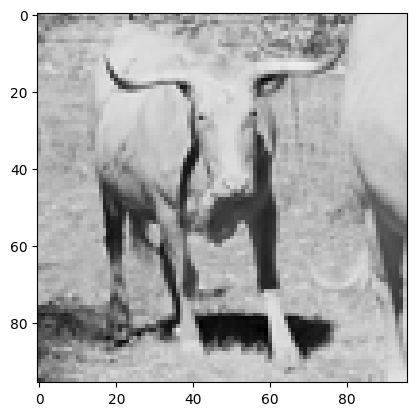

In [ ]:
import matplotlib.pyplot as plt
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    plt.figure(figsize=(5, 5))
    plt.imshow(canvas)
    plt.axis('off')
    plt.show()


In [ ]:
a,b = test_generator.__getitem__(1)

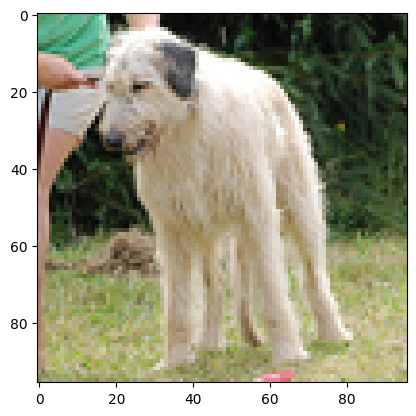

In [ ]:
plt.imshow(b[4])

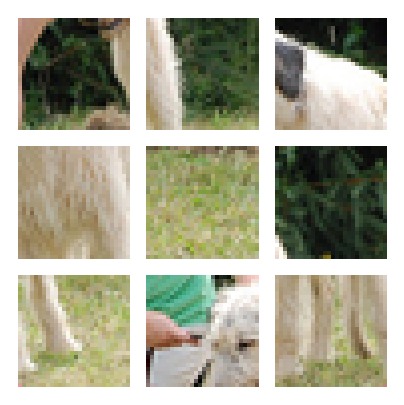

In [ ]:
plot_puzzle(a[4])

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [ ]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image
    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [ ]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))
print("MAE:", tf.reduce_mean(mae_values))
print("std:", tf.math.reduce_std(mae_values))

MAE: tf.Tensor(0.1826404, shape=(), dtype=float32)
std: tf.Tensor(0.001000533, shape=(), dtype=float32)


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.





# Using Google Drive
Let's use Google Drive to save checkpoints of our model in case of Colab disconnection

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

checkpoint_dir = '/content/drive/MyDrive/Jigsaw_Project_Checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

Mounted at /content/drive


# Model construction

The architecture consists of several key stages:

1.  **Patch Input**: Takes a batch of 9 scrambled 28x28x3 image patches as input.
2.  **Robust Encoder**: A TimeDistributed CNN extracts rich features from each individual patch. This helps in understanding the content of each patch independently.
3.  **Transformer**: A Transformer block processes the encoded patch features. It uses positional embeddings to incorporate spatial information and multi-head attention mechanisms to model the relationships and dependencies between the patches, inferring their correct relative positions.
4.  **Sinkhorn Router**: A custom SinkhornRouting layer takes the output from the Transformer to generate a permutation matrix. This matrix mathematically enforces a one-to-one assignment, strictly determining the optimal placement for each patch in the reconstructed image.
5.  **Physical Reordering of Original Patches**: The generated permutation matrix is used to reorder the *original* input patches according to the inferred spatial arrangement.
6.  **Canvas Assembly**: The reordered patches are then padded and assembled into a 96x96x3 canvas. This initial canvas may have gaps due to the erosion during patch generation and is the starting point for inpainting.
7.  **Deep U-Net for Inpainting**: A U-Net like architecture takes the assembled canvas as input. This network is responsible for filling in the missing visual content and refining the overall image to produce a coherent, artifact-free reconstruction. It adds a residual to the canvas, and the final output is passed through a sigmoid activation to ensure pixel values are in the range [0, 1].

In [ ]:
import tensorflow as tf
import keras
from keras import layers, models, ops

@keras.saving.register_keras_serializable(package="CustomLayers")
class SinkhornRouting(layers.Layer):
    def __init__(self, n_iters=5, tau=0.1, **kwargs):
        super().__init__(**kwargs)
        self.n_iters = n_iters
        self.tau = tau

    def call(self, logits):
        # The Sinkhorn algorithm iteratively normalizes rows and columns
        # to mathematically enforce a doubly stochastic (1-to-1) matrix.
        log_alpha = logits / self.tau
        for _ in range(self.n_iters):
            log_alpha = log_alpha - ops.logsumexp(log_alpha, axis=-1, keepdims=True)
            log_alpha = log_alpha - ops.logsumexp(log_alpha, axis=-2, keepdims=True)
        return ops.exp(log_alpha)

    def get_config(self):
        config = super().get_config()
        config.update({"n_iters": self.n_iters, "tau": self.tau})
        return config

def build_model():
    # ==========================================
    # 1. PATCH INPUT
    # ==========================================
    input_patches = layers.Input(shape=(9, 28, 28, 3), name="input_patches")

    # ==========================================
    # 2. ROBUST ENCODER (Extract rich features)
    # ==========================================
    # TimeDistributed applies the Conv2D and other layers independently to each of the 9 patches.
    # Conv2D layers with increasing filters extract features and downsample spatial dimensions.
    # GlobalAveragePooling2D reduces each patch's feature map to a single feature vector.
    # Dense layer further processes these feature vectors.
    x = layers.TimeDistributed(layers.Conv2D(64, (3, 3), strides=2, padding='same', activation=layers.LeakyReLU(alpha=0.2)))(input_patches)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.Conv2D(128, (3, 3), strides=2, padding='same', activation=layers.LeakyReLU(alpha=0.2)))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.Conv2D(256, (3, 3), strides=2, padding='same', activation=layers.LeakyReLU(alpha=0.2)))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    x = layers.TimeDistributed(layers.Dense(256, activation=layers.LeakyReLU(alpha=0.2)))(x)
    x = layers.TimeDistributed(layers.BatchNormalization())(x)

    # ==========================================
    # 3. TRANSFORMER (Understand context and position)
    # ==========================================
    # Positional embeddings are added to patch features to inject spatial information.
    # MultiHeadAttention blocks allow the model to weigh the importance of different patches.
    # LayerNormalization implement residual connections and normalize activations.
    positions = ops.arange(start=0, stop=9, step=1)
    pos_emb = layers.Embedding(input_dim=9, output_dim=256)(positions)
    x = x + pos_emb

    # Attention Block 1
    attn_out1 = layers.MultiHeadAttention(num_heads=8, key_dim=32)(x, x)
    x = layers.Add()([x, attn_out1])
    x = layers.LayerNormalization()(x)
    ffn_out1 = layers.TimeDistributed(layers.Dense(256, activation=layers.LeakyReLU(alpha=0.2)))(x)
    ffn_out1 = layers.TimeDistributed(layers.BatchNormalization())(ffn_out1)
    x = layers.Add()([x, ffn_out1])
    x = layers.LayerNormalization()(x)

    # Attention Block 2
    attn_out2 = layers.MultiHeadAttention(num_heads=8, key_dim=32)(x, x)
    x = layers.Add()([x, attn_out2])
    x = layers.LayerNormalization()(x)
    ffn_out2 = layers.TimeDistributed(layers.Dense(256, activation=layers.LeakyReLU(alpha=0.2)))(x)
    ffn_out2 = layers.TimeDistributed(layers.BatchNormalization())(ffn_out2)
    x = layers.Add()([x, ffn_out2])
    x = layers.LayerNormalization()(x)

    # ==========================================
    # 4. SINKHORN ROUTER (Strict mathematical assignment)
    # ==========================================
    # Dense layer predicts logits for the permutation matrix.
    # SinkhornRouting applies the Sinkhorn-Knopp algorithm to turn logits into a doubly stochastic matrix.
    # n_iters=5: number of iterations for Sinkhorn algorithm.
    # tau=0.1: temperature parameter for softmax, controlling output sharpness.
    perm_logits = layers.Dense(9)(x)
    perm_matrix = SinkhornRouting(n_iters=5, tau=0.1)(perm_logits)

    # ==========================================
    # 5. PHYSICAL REORDERING OF ORIGINAL PATCHES
    # ==========================================
    # The permutation matrix is used to reorder the *original* input patches.
    # Reshape and Permute prepare tensors for matrix multiplication.
    # Dot product performs the actual reordering based on the learned permutation matrix.
    flat_patches = layers.Reshape((9, 28 * 28 * 3))(input_patches)
    perm_matrix_t = layers.Permute((2, 1))(perm_matrix)
    reordered_flat = layers.Dot(axes=(2, 1))([perm_matrix_t, flat_patches])
    reordered_patches = layers.Reshape((9, 28, 28, 3))(reordered_flat)

    # ==========================================
    # 6. CANVAS ASSEMBLY
    # ==========================================
    # Patches are padded to 32x32 to create gaps for inpainting when assembled into a 96x96 canvas.
    # Reshape and Permute operations arrange the individual padded patches into a 3x3 grid to form the full image.
    padded = layers.TimeDistributed(layers.ZeroPadding2D(padding=(2, 2)))(reordered_patches)
    grid = layers.Reshape((3, 3, 32, 32, 3))(padded)
    grid = layers.Permute((1, 3, 2, 4, 5))(grid)
    canvas = layers.Reshape((96, 96, 3), name="canvas")(grid)

    # ==========================================
    # 7. DEEP U-NET FOR INPAINTING
    # ==========================================
    # A U-Net architecture is used for inpainting the gaps and refining the reconstructed image.
    # Downsampling path (Down 1, 2, 3) extracts features at multiple scales using Conv2D and MaxPooling2D.
    # Bottleneck layer further processes features.
    # Upsampling path (Up 3, 2, 1) reconstructs the image, using Conv2DTranspose and concatenation with skip connections (c1, c2, c3).
    # Filters (64, 128, 256, 192) increase in downsampling and decrease in upsampling.
    # The final Conv2D layer produces the residual, which is added to the initial canvas.
    # Sigmoid activation ensures output pixel values are between 0 and 1.
    # Down 1
    c1 = layers.Conv2D(64, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(canvas)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Conv2D(64, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(c1)
    c1 = layers.BatchNormalization()(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Down 2
    c2 = layers.Conv2D(128, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Conv2D(128, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(c2)
    c2 = layers.BatchNormalization()(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Down 3
    c3 = layers.Conv2D(256, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Conv2D(256, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(c3)
    c3 = layers.BatchNormalization()(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(192, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(p3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Conv2D(192, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(c4)
    c4 = layers.BatchNormalization()(c4)

    # Up 3
    u3 = layers.Conv2DTranspose(192, (2, 2), strides=(2, 2), padding='same')(c4)
    u3 = layers.BatchNormalization()(u3)
    u3 = layers.Concatenate()([u3, c3])
    d3 = layers.Conv2D(192, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(u3)
    d3 = layers.BatchNormalization()(d3)
    d3 = layers.Conv2D(192, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(d3)
    d3 = layers.BatchNormalization()(d3)

    # Up 2
    u2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(d3)
    u2 = layers.BatchNormalization()(u2)
    u2 = layers.Concatenate()([u2, c2])
    d2 = layers.Conv2D(128, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(u2)
    d2 = layers.BatchNormalization()(d2)
    d2 = layers.Conv2D(128, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(d2)
    d2 = layers.BatchNormalization()(d2)

    # Up 1
    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d2)
    u1 = layers.BatchNormalization()(u1)
    u1 = layers.Concatenate()([u1, c1])
    d1 = layers.Conv2D(64, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(u1)
    d1 = layers.BatchNormalization()(d1)
    d1 = layers.Conv2D(64, (3, 3), padding='same', activation=layers.LeakyReLU(alpha=0.2))(d1)
    d1 = layers.BatchNormalization()(d1)

    # Final output layer (calculates the residual for inpainting)
    unet_out = layers.Conv2D(3, (3, 3), padding='same', activation='linear')(d1)

    # Residual connection to the canvas and sigmoid activation for final output image.
    output_image = layers.Activation('sigmoid', name="reconstructed_image")(canvas + unet_out)

    model = models.Model(inputs=input_patches, outputs=output_image, name="Jigsaw_Model")
    return model


In [ ]:
model = build_model()

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Jigsaw_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_patches       │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 9, 14, 14, │      1,792 │ input_patches[0]… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 9, 14, 14, │        256 │ time_distributed… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 9, 7, 7,   │     73,856 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 9, 7, 7,   │        512 │ time_distributed… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 9, 4, 4,   │    295,168 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 9, 4, 4,   │      1,024 │ time_distributed… │
│ (TimeDistributed)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 9, 256)    │          0 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 9, 256)    │     65,792 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 9, 256)    │      1,024 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 9, 256)    │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 9, 256)    │    263,168 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 256)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 9, 256)    │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 9, 256)    │     65,792 │ layer_normalizat… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 9, 256)    │      1,024 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 9, 256)    │          0 │ layer_normalizat… │
│                     │                   │            │ time_distributed

 Total params: 4,973,708 (18.97 MB)

 Trainable params: 4,966,412 (18.95 MB)

 Non-trainable params: 7,296 (28.50 KB)

In [ ]:
checkpoint_dir = '/content/drive/MyDrive/Jigsaw_Project_Checkpoints'

# 1. Callback for backup and restore in google drive
backup_callback = keras.callbacks.BackupAndRestore(
    backup_dir=os.path.join(checkpoint_dir, "backup")
)

# 2. Callback for saving the best model
checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "best_jigsaw_model.keras"),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# 3. Dynamic LR reduction
lr_reducer_callback = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)


my_callbacks = [backup_callback, checkpoint_callback, lr_reducer_callback]



In [ ]:
# Compilation: We use AdamW with weight decay to effectively regularize the Transformer
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss='mae',
    metrics=['mae']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    callbacks=my_callbacks
)

Epoch 194/200
 9999/10000 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0440 - mae: 0.0440
Epoch 194: val_loss did not improve from 0.04751
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 228s 17ms/step - loss: 0.0439 - mae: 0.0439 - val_loss: 0.0476 - val_mae: 0.0476 - learning_rate: 1.0000e-06
Epoch 195/200
 9998/10000 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0438 - mae: 0.0438
Epoch 195: val_loss did not improve from 0.04751
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 160s 16ms/step - loss: 0.0438 - mae: 0.0438 - val_loss: 0.0476 - val_mae: 0.0476 - learning_rate: 1.0000e-06
Epoch 196/200
 9999/10000 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0437 - mae: 0.0437
Epoch 196: val_loss did not improve from 0.04751
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 159s 16ms/step - loss: 0.0438 - mae: 0.0438 - val_loss: 0.0476 - val_mae: 0.0476 - learning_rate: 1.0000e-06
Epoch 197/200
 9999/10000 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0436 - mae: 0.0436
Epoch 197: val_loss did not improve from 0.04751
10000/10000 ━━━━━━━━━━

In [ ]:
import gdown
from keras.models import load_model

file_id = '1HxgJPoTr0JcFl2NoyQA8dX_RkPzwfzxo'
url = f'https://drive.google.com/uc?id={file_id}'
output_path = 'best_jigsaw_model.keras'

print("Downloading model weights...")
gdown.download(url, output_path, quiet=False)

jigsaw_model = load_model(output_path, safe_mode=False)
print("Model loaded successfully!")

Downloading...
From (original): https://drive.google.com/uc?id=1HxgJPoTr0JcFl2NoyQA8dX_RkPzwfzxo
From (redirected): https://drive.google.com/uc?id=1HxgJPoTr0JcFl2NoyQA8dX_RkPzwfzxo&confirm=t&uuid=1130b207-3335-4200-9ee8-54ea1200da37
To: /content/best_jigsaw_model.keras
100%|██████████| 60.2M/60.2M [00:00<00:00, 155MB/s]


Model loaded successfully!


In [ ]:

# List to store the MAE of each batch
batch_maes = []

print("Evaluating model on test_generator...")

for i in range(len(test_generator)):
    a, b = test_generator.__getitem__(i)

    pred = jigsaw_model(a, training=False)

    # Calculation of MAE for this batch
    mae_per_sample = tf.reduce_mean(tf.abs(pred - b), axis=[1, 2, 3])

    # Adding MAE to the list
    batch_maes.extend(mae_per_sample.numpy())

batch_maes = np.array(batch_maes)

# Final metrics
model_mae_mean = np.mean(batch_maes)
model_mae_std = np.std(batch_maes)

print("\n=== RESULTS ===")
print(f"MAE: {model_mae_mean:.5f}")
print(f"STD: {model_mae_std:.5f}")

Evaluating model on test_generator...

=== RESULTS ===
MAE: 0.04853
STD: 0.04650


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


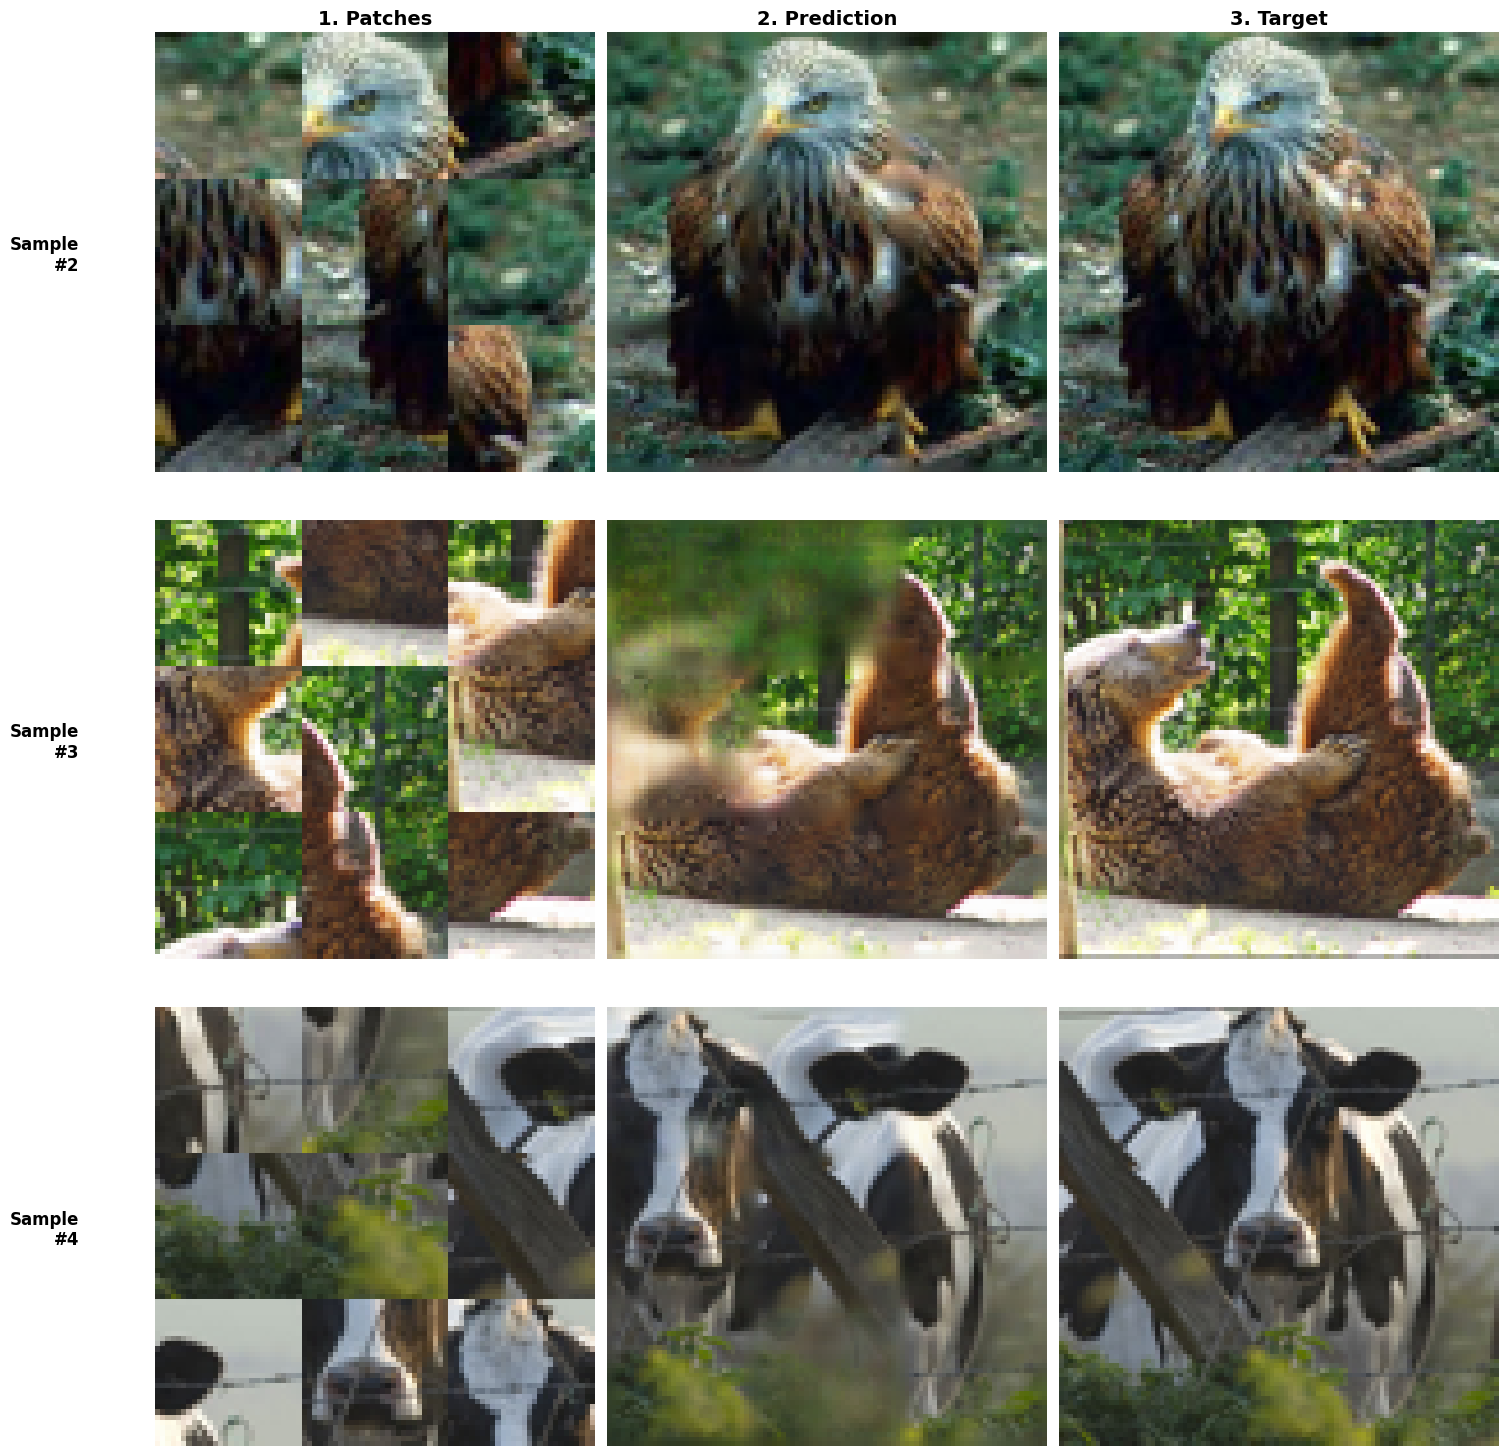

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_evaluatin_samples(generator, model, start_sample_index=0):
    X_batch, Y_batch = generator.__getitem__(0)

    # Our plot will be 3x3
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    for row_idx in range(3):
        sample_idx = start_sample_index + row_idx

        patches = X_batch[sample_idx]
        original = Y_batch[sample_idx]

        # Model prediction
        input_tensor = np.expand_dims(patches, axis=0)
        reconstructed = model.predict(input_tensor)[0]
        reconstructed = np.clip(reconstructed, 0.0, 1.0)

        # ---------------------------------------------------------------------
        # COLUMN 1: Input patches
        # ---------------------------------------------------------------------
        ax_patches = axes[row_idx, 0]
        canvas = np.zeros((3 * 28, 3 * 28, 3))
        patch_idx = 0
        for r in range(3):
            for c in range(3):
                canvas[r*28:(r+1)*28, c*28:(c+1)*28, :] = patches[patch_idx]
                patch_idx += 1
        ax_patches.imshow(canvas)
        ax_patches.axis('off')
        if row_idx == 0:
            ax_patches.set_title("1. Patches", fontsize=14, fontweight='bold')

        ax_patches.text(-15, 42, f"Sample\n#{sample_idx}", va='center', ha='right', fontsize=12, fontweight='bold')

        # ---------------------------------------------------------------------
        # COLUMN 2: Prediction
        # ---------------------------------------------------------------------
        ax_pred = axes[row_idx, 1]
        ax_pred.imshow(reconstructed)
        ax_pred.axis('off')
        if row_idx == 0:
            ax_pred.set_title("2. Prediction", fontsize=14, fontweight='bold')

        # ---------------------------------------------------------------------
        # COLUMN 3: Target image
        # ---------------------------------------------------------------------
        ax_target = axes[row_idx, 2]
        ax_target.imshow(original)
        ax_target.axis('off')
        if row_idx == 0:
            ax_target.set_title("3. Target", fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_evaluatin_samples(test_generator, jigsaw_model, start_sample_index=2)